# RQ1: What Key Factors Lead to Late Deliveries, and How Can We Proactively Identify High-Risk Orders to Improve Customer Satisfaction?

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, precision_recall_curve, average_precision_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.calibration import CalibratedClassifierCV
from tensorflow.keras.losses import BinaryFocalCrossentropy
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import fbeta_score

## Importing Dataset

In [3]:
data = pd.read_csv("../data/cleaned/cleaned_dataset.csv")

data.head()

,order_id,order_item_id,order_status,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,is_canceled,customer_id,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume,review_id,review_score,delivered_late,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,delivered,2017-10-02,2017-10-02,2017-10-18,False,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,1976.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,False,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,delivered,2018-07-24,2018-07-26,2018-08-13,False,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,4693.0,8d5266042046a06655c8db133d120ba5,4.0,False,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,delivered,2018-08-08,2018-08-08,2018-09-04,False,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,9576.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,False,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,delivered,2017-11-18,2017-11-18,2017-12-15,False,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,...,3.0,450.0,30.0,10.0,20.0,6000.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,False,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,delivered,2018-02-13,2018-02-13,2018-02-26,False,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,4.0,250.0,51.0,15.0,15.0,11475.0,e50934924e227544ba8246aeb3770dd4,5.0,False,-10.0


In [4]:
data.columns

Index(['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'is_canceled',
       'customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'customer_lat', 'customer_lng',
       'order_delivered_customer_date', 'is_first_time_buyer', 'seller_id',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat',
       'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date',
       'handoff_delay', 'distance_km', 'product_id',
       'product_category_name_english', 'price', 'freight_value',
       'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'product_volume', 'review_id',
       'review_score', 'delivered_late', 'delivery_delay'],
      dtype='object')

## Pre-Processing

### Removing Unnecessary Columns

In [5]:
data.drop(columns=['order_id', 
                   'order_item_id', 
                   'order_status', 
                   'order_purchase_timestamp', 
                   'order_approved_at',
                   'order_estimated_delivery_date',
                   'is_canceled',
                   'customer_id',
                   'customer_unique_id',
                   'customer_zip_code_prefix',
                   'customer_state',
                   'customer_lat',
                   'customer_lng',
                   'order_delivered_customer_date',
                   'is_first_time_buyer',
                   'seller_zip_code_prefix',
                   'seller_state',
                   'seller_lat',
                   'seller_lng',
                   'shipping_limit_date',
                   'order_delivered_carrier_date',
                   'price',
                   'freight_value',
                   'product_name_length',
                   'product_description_length',
                   'product_photos_qty',
                   'review_id',
                   'review_score',
                   'product_id',
                   'delivery_delay'], inplace=True)

display(data.head())

display(data.shape)

,customer_city,seller_id,seller_city,handoff_delay,distance_km,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume,delivered_late
0,sao paulo,3504c0cb71d7fa48d967e0e4c94d59d9,maua,-2.0,18.576110,housewares,500.0,19.0,8.0,13.0,1976.0,False
1,barreiras,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,-4.0,851.495069,perfumery,400.0,19.0,13.0,19.0,4693.0,False
2,vianopolis,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,-5.0,514.410666,auto,420.0,24.0,19.0,21.0,9576.0,False
3,sao goncalo do amarante,66922902710d126a0e7d26b0e3805106,belo horizonte,-1.0,1822.226336,pet_shop,450.0,30.0,10.0,20.0,6000.0,False
4,santo andre,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,-5.0,29.676625,stationery,250.0,51.0,15.0,15.0,11475.0,False


(111717, 12)

### Removing NA Rows

In [6]:
data = data.dropna()

display(data.shape)

(108983, 12)

### Variable Selection

In [7]:
X = data.drop(columns=['delivered_late'])
y = data['delivered_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Encoding Variables

In [8]:
categorical_features = ['customer_city',
                        'seller_city', 
                        'seller_id',
                        'product_category_name_english']

numerical_features = ['handoff_delay', 'distance_km', 'product_weight_g',
                      'product_length_cm', 'product_height_cm',
                      'product_width_cm', 'product_volume']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

### Getting Feature Names

In [9]:
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

# Get column names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_feature_names)

### Applying SMOTE

In [10]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)

### Applying StratifiedKFold

In [11]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Focusing Recall for the Positive Late Deliveries

In [12]:
recall_scorer = make_scorer(recall_score, pos_label=True)

## Logistic Regression

### Creating the Best Model

In [13]:
# Logistic regression model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Hyperparameter grid (penalty type and C values)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']  # Try both L1 and L2 regularization
}

# Grid search setup
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit model
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# Extract best model and params
best_log_reg = grid_log_reg.best_estimator_
print("Best Parameters:", grid_log_reg.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.01, penalty=l1; total time= 1.7min
[CV] END .................................C=0.01, penalty=l1; total time= 1.4min
[CV] END .................................C=0.01, penalty=l1; total time= 1.4min
[CV] END .................................C=0.01, penalty=l1; total time= 1.2min
[CV] END .................................C=0.01, penalty=l1; total time= 1.2min
[CV] END .................................C=0.01, penalty=l2; total time= 1.3min
[CV] END .................................C=0.01, penalty=l2; total time= 1.3min
[CV] END .................................C=0.01, penalty=l2; total time= 1.2min
[CV] END .................................C=0.01, penalty=l2; total time= 1.2min
[CV] END .................................C=0.01, penalty=l2; total time= 1.2min
[CV] END ..................................C=0.1, penalty=l1; total time= 1.3min
[CV] END ..................................C=0.1,

### Testing the Model


Optimal Threshold (LogReg): 0.5074

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

       False       0.96      0.77      0.86     20393
        True       0.15      0.59      0.24      1404

    accuracy                           0.76     21797
   macro avg       0.56      0.68      0.55     21797
weighted avg       0.91      0.76      0.82     21797

ROC-AUC Score: 0.7257


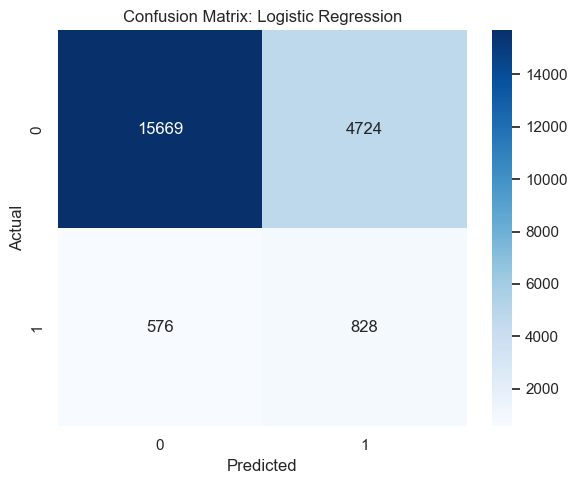

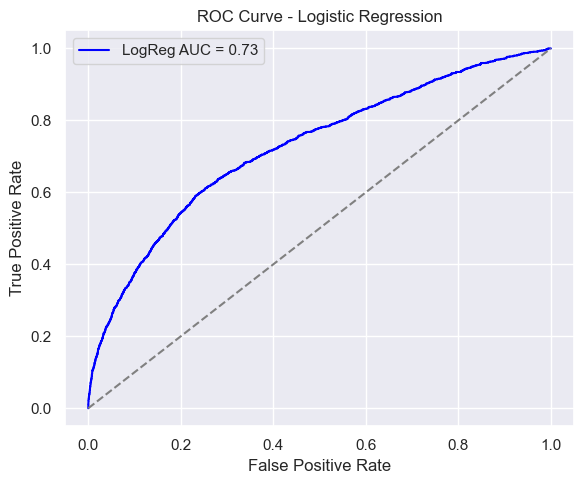

In [14]:
# Predict probabilities
y_proba_logreg = best_log_reg.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logreg)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-6)
optimal_threshold_logreg = thresholds[np.argmax(f2_scores)]
print(f"\nOptimal Threshold (LogReg): {optimal_threshold_logreg:.4f}")

# Apply optimal threshold
y_pred_logreg_opt = (y_proba_logreg >= optimal_threshold_logreg).astype(int)

# Metrics
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg_opt))

roc_auc = roc_auc_score(y_test, y_proba_logreg)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

### Log-Odds


Top Logistic Regression Coefficients (Log-Odds):


customer_city_santa cruz de goias           14.612578
customer_city_passira                       10.619587
customer_city_jacuizinho                     9.733849
customer_city_apora                          9.609735
customer_city_ribeiro junqueira              9.296297
customer_city_arace                          9.222276
customer_city_vila nelita                    9.112208
customer_city_vargem grande do rio pardo     8.947842
customer_city_sao sebastiao de campos        8.942357
customer_city_sao joao de pirabas            8.888312
customer_city_igapora                        8.874807
customer_city_america dourada                8.874310
customer_city_conde                          8.792097
customer_city_glicerio                       8.764868
customer_city_ibiraja                        8.720648
dtype: float64

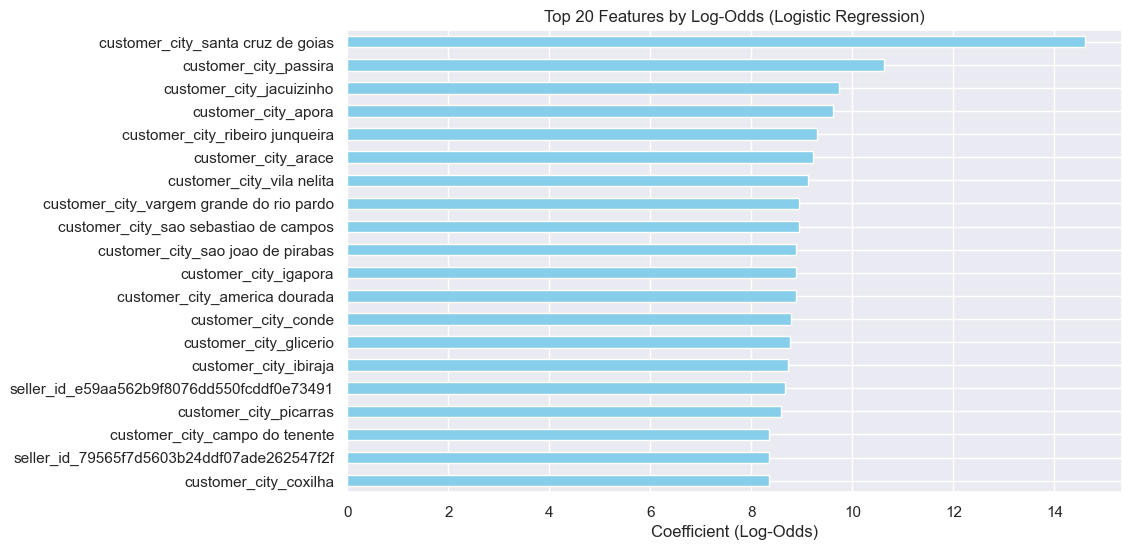

In [16]:
# === Logistic Regression Coefficients (Log-Odds) ===
log_odds = pd.Series(best_log_reg.coef_[0], index=X_train_df.columns)
log_odds_sorted = log_odds.sort_values(key=abs, ascending=False)

# Display top 15 features with strongest influence
print("\nTop Logistic Regression Coefficients (Log-Odds):")
display(log_odds_sorted.head(15))

# Plot
plt.figure(figsize=(10, 6))
log_odds_sorted.head(20).plot(kind='barh', color='skyblue')
plt.title("Top 20 Features by Log-Odds (Logistic Regression)")
plt.xlabel("Coefficient (Log-Odds)")
plt.gca().invert_yaxis()
plt.show()

## Decision Tree

### Creating the Best Model

In [15]:
# Define the Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search
grid_tree = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_tree,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit to the resampled training set
grid_tree.fit(X_train_resampled, y_train_resampled)

# Best model and parameters
best_tree = grid_tree.best_estimator_
print("Best Parameters:", grid_tree.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  56.3s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  58.3s
[CV] END .criterion=gini, max_depth=10, min_samples_split=10; total time= 1.2min
[CV] END .criterion=gini, max_depth=10, min_samp

### Evaluting the Model


Optimal Threshold (Decision Tree): 0.1355

Classification Report (Decision Tree):
              precision    recall  f1-score   support

       False       0.97      0.40      0.56     20393
        True       0.08      0.80      0.15      1404

    accuracy                           0.42     21797
   macro avg       0.53      0.60      0.36     21797
weighted avg       0.91      0.42      0.54     21797

ROC-AUC Score (Tree): 0.6511


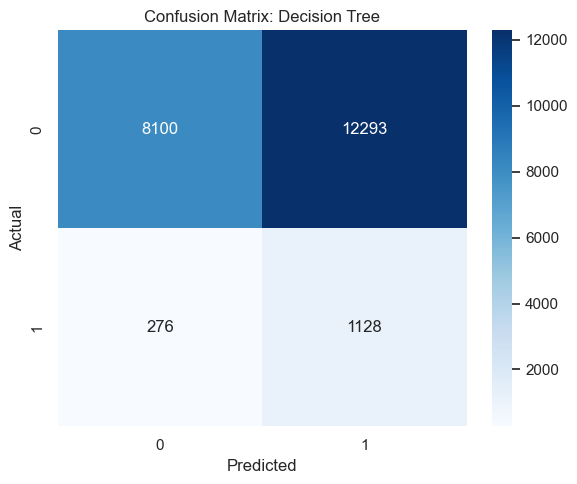

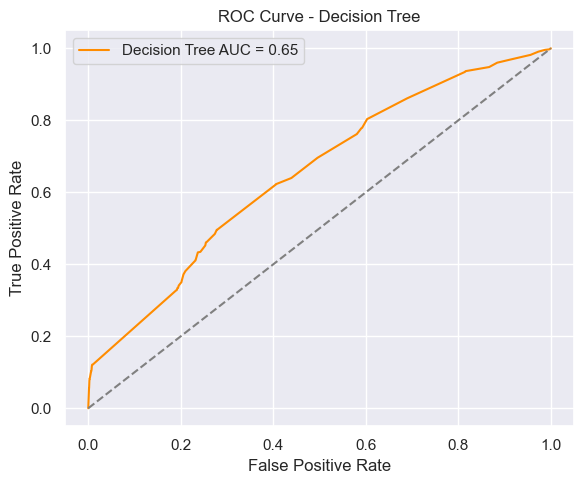

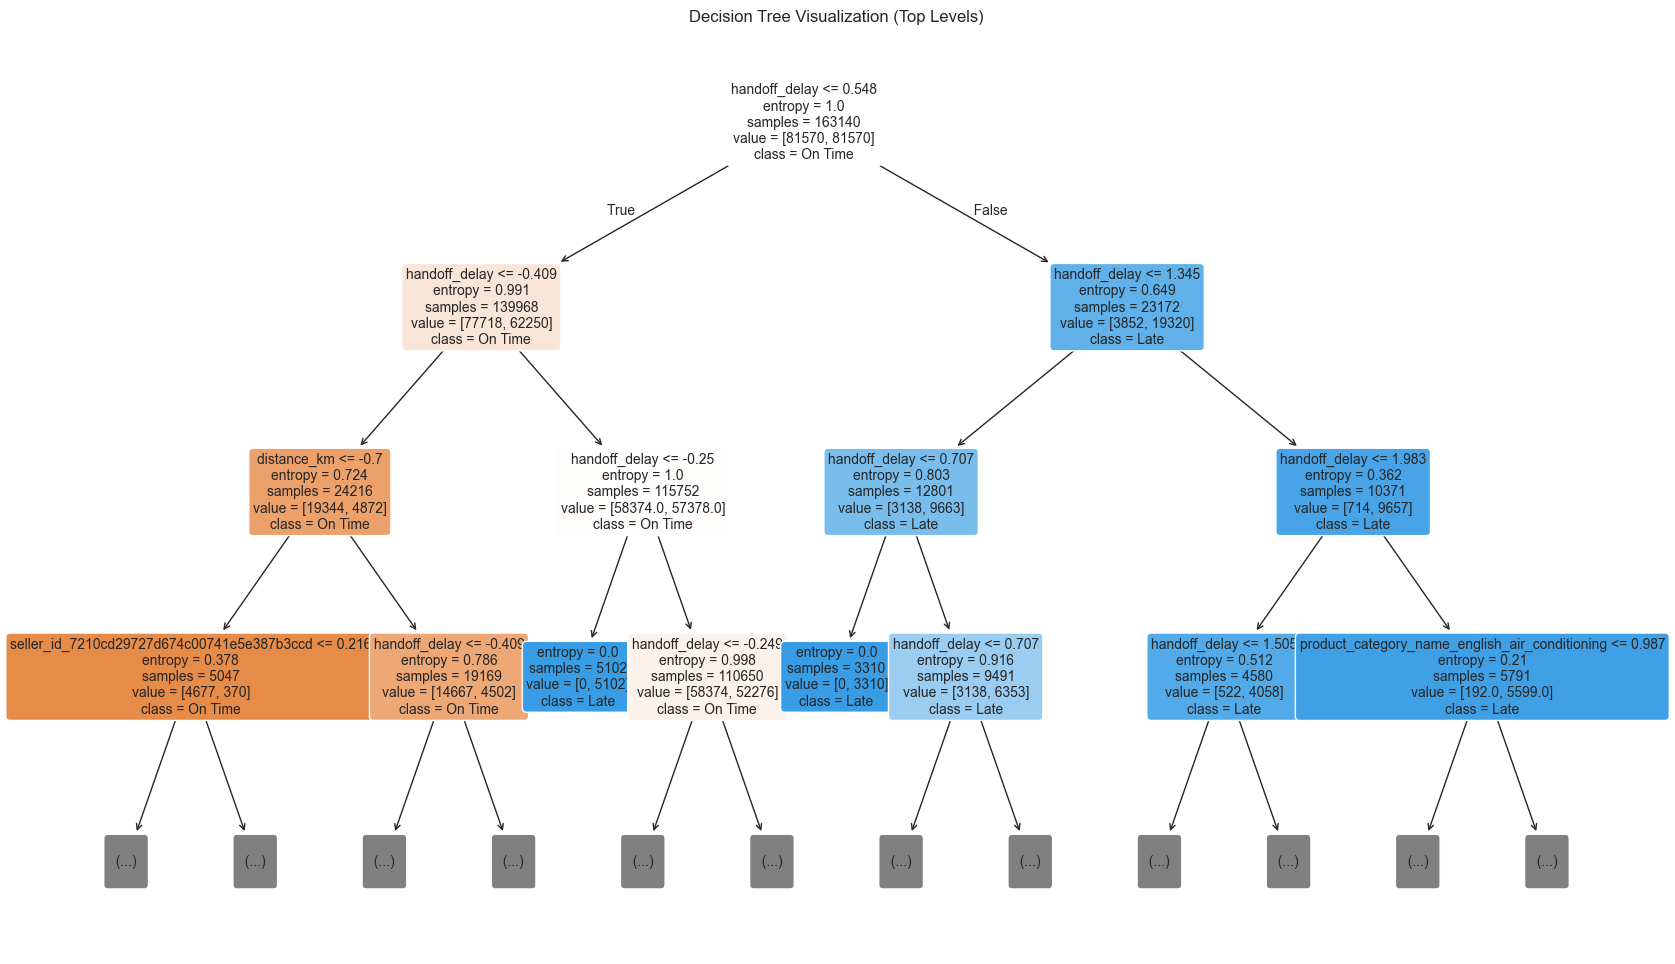

In [16]:
# Predict probabilities
y_proba_tree = best_tree.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_tree, recall_tree, thresholds_tree = precision_recall_curve(y_test, y_proba_tree)
f2_scores_tree = 5 * (precision_tree * recall_tree) / (4 * precision_tree + recall_tree + 1e-6)
optimal_threshold_tree = thresholds_tree[np.argmax(f2_scores_tree)]
print(f"\nOptimal Threshold (Decision Tree): {optimal_threshold_tree:.4f}")

# Apply optimal threshold
y_pred_tree_opt = (y_proba_tree >= optimal_threshold_tree).astype(int)

# Metrics
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree_opt))

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
print(f"ROC-AUC Score (Tree): {roc_auc_tree:.4f}")

# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.figure(figsize=(6, 5))
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {roc_auc_tree:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Visualizing the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(
    best_tree, 
    feature_names=all_feature_names, 
    class_names=['On Time', 'Late'], 
    filled=True, 
    rounded=True, 
    fontsize=10,
    max_depth=3  # limit depth for readability, remove or increase to see more
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

## Random Forest

### Creating the Best Model

In [17]:
# Random Forest
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']  # Helps handle imbalance without SMOTE here, but still okay if you keep SMOTE
}

grid_rf = GridSearchCV(
                        estimator=rf_clf, 
                        param_grid=param_grid_rf,
                        scoring=recall_scorer, 
                        cv=stratified_cv, 
                        verbose=2, 
                        n_jobs=1
                    )

grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.2min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.2min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.7min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.7min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.

### Evaluating the Model


Optimal Threshold (Random Forest): 0.4846

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       0.97      0.67      0.79     20393
        True       0.12      0.65      0.20      1404

    accuracy                           0.67     21797
   macro avg       0.54      0.66      0.50     21797
weighted avg       0.91      0.67      0.75     21797

ROC-AUC Score (Random Forest): 0.7067


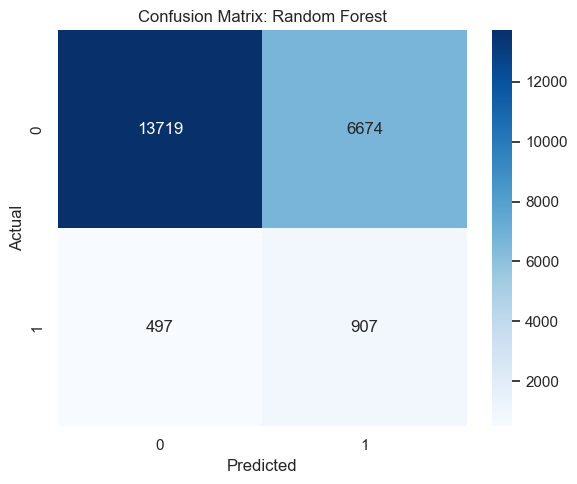

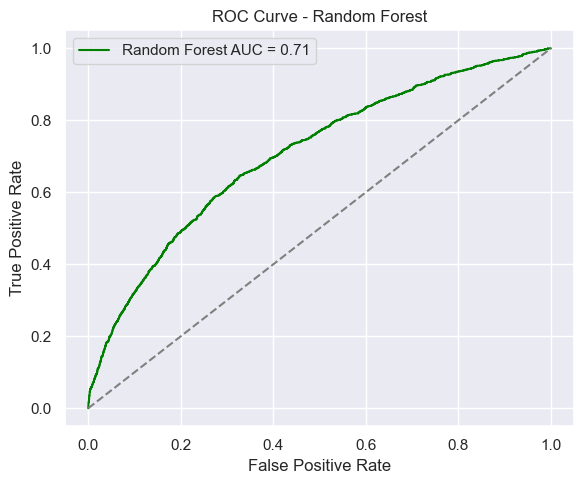

In [18]:
# Predict probabilities
y_proba_rf = best_rf.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
f2_scores_rf = 5 * (precision_rf * recall_rf) / (4 * precision_rf + recall_rf + 1e-6)
optimal_threshold_rf = thresholds_rf[np.argmax(f2_scores_rf)]
print(f"\nOptimal Threshold (Random Forest): {optimal_threshold_rf:.4f}")

# Apply optimal threshold
y_pred_rf_opt = (y_proba_rf >= optimal_threshold_rf).astype(int)

# Metrics
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf_opt))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## XGBoost

### Creating the Model

In [14]:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
                        estimator=xgb_clf, 
                        param_grid=param_grid_xgb,
                        scoring=recall_scorer, 
                        cv=stratified_cv, 
                        verbose=2, 
                        n_jobs=1
                        )

grid_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb = grid_xgb.best_estimator_
print("Best Parameters (XGBoost):", grid_xgb.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time= 2.9min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time= 3.2min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time= 3.4min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time= 3.3min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time= 3.3min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time= 3.3min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time= 3.3min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time= 3.4min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time= 3.3min
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time= 3.3mi

### Evaluating the Model


Optimal Threshold (XGBoost): 0.1780

Classification Report (XGBoost):
              precision    recall  f1-score   support

       False       0.97      0.76      0.85     20393
        True       0.15      0.60      0.24      1404

    accuracy                           0.75     21797
   macro avg       0.56      0.68      0.54     21797
weighted avg       0.91      0.75      0.81     21797

ROC-AUC Score (XGBoost): 0.7419


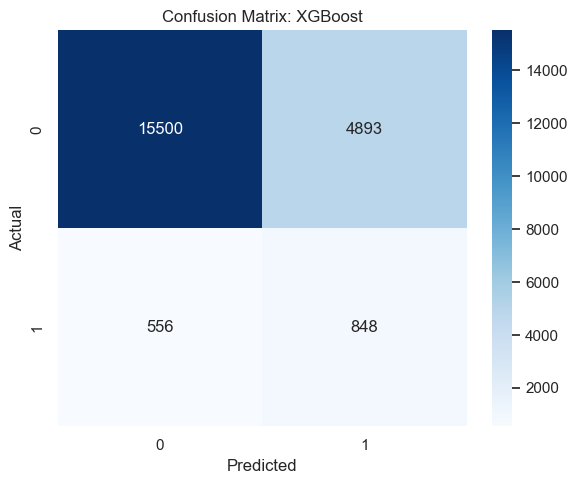

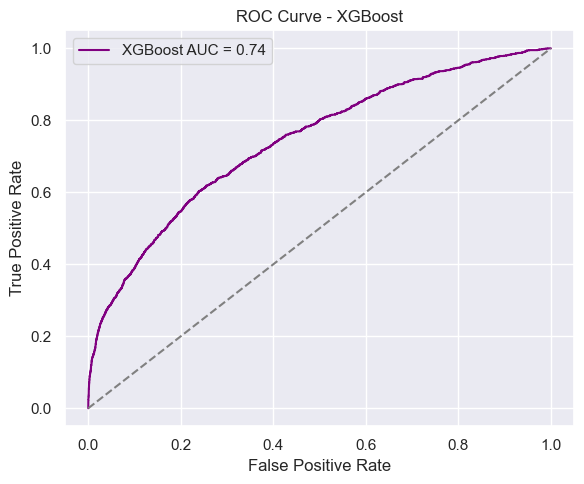

In [15]:
# Predict probabilities
y_proba_xgb = best_xgb.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)
f2_scores_xgb = 5 * (precision_xgb * recall_xgb) / (4 * precision_xgb + recall_xgb + 1e-6)
optimal_threshold_xgb = thresholds_xgb[np.argmax(f2_scores_xgb)]
print(f"\nOptimal Threshold (XGBoost): {optimal_threshold_xgb:.4f}")

# Apply threshold
y_pred_xgb_opt = (y_proba_xgb >= optimal_threshold_xgb).astype(int)

# Metrics
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb_opt))

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score (XGBoost): {roc_auc_xgb:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.2f}", color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

## ANN

### Creating the Model

In [21]:
# Define the ANN model
def create_complex_ann():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_resampled.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    focal_loss = BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=focal_loss, metrics=['Recall'])
    return model

# Wrap in KerasClassifier for calibration
keras_clf = KerasClassifier(model=create_complex_ann, epochs=15, batch_size=32, verbose=2)
keras_clf.fit(X_train_resampled, y_train_resampled)

c:\Users\mesha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
5099/5099 - 61s - 12ms/step - Recall: 0.7910 - loss: 0.1293
Epoch 2/15
5099/5099 - 56s - 11ms/step - Recall: 0.8952 - loss: 0.0755
Epoch 3/15
5099/5099 - 53s - 10ms/step - Recall: 0.9213 - loss: 0.0593
Epoch 4/15
5099/5099 - 51s - 10ms/step - Recall: 0.9335 - loss: 0.0523
Epoch 5/15
5099/5099 - 52s - 10ms/step - Recall: 0.9399 - loss: 0.0479
Epoch 6/15
5099/5099 - 51s - 10ms/step - Recall: 0.9445 - loss: 0.0455
Epoch 7/15
5099/5099 - 51s - 10ms/step - Recall: 0.9481 - loss: 0.0428
Epoch 8/15
5099/5099 - 51s - 10ms/step - Recall: 0.9522 - loss: 0.0406
Epoch 9/15
5099/5099 - 51s - 10ms/step - Recall: 0.9536 - loss: 0.0393
Epoch 10/15
5099/5099 - 51s - 10ms/step - Recall: 0.9558 - loss: 0.0377
Epoch 11/15
5099/5099 - 51s - 10ms/step - Recall: 0.9581 - loss: 0.0367
Epoch 12/15
5099/5099 - 50s - 10ms/step - Recall: 0.9592 - loss: 0.0357
Epoch 13/15
5099/5099 - 51s - 10ms/step - Recall: 0.9608 - loss: 0.0346
Epoch 14/15
5099/5099 - 51s - 10ms/step - Recall: 0.9629 - loss: 0.0330
E

,model,<function cre...001E6C73A76A0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,32
,validation_batch_size,None
,verbose,2
,callbacks,None


### Evaluating the Model

682/682 - 1s - 2ms/step

Optimal Threshold (ANN): 0.1880

Classification Report (ANN):
              precision    recall  f1-score   support

       False       0.96      0.73      0.83     20393
        True       0.13      0.59      0.22      1404

    accuracy                           0.72     21797
   macro avg       0.55      0.66      0.52     21797
weighted avg       0.91      0.72      0.79     21797

ROC-AUC Score (ANN): 0.7081


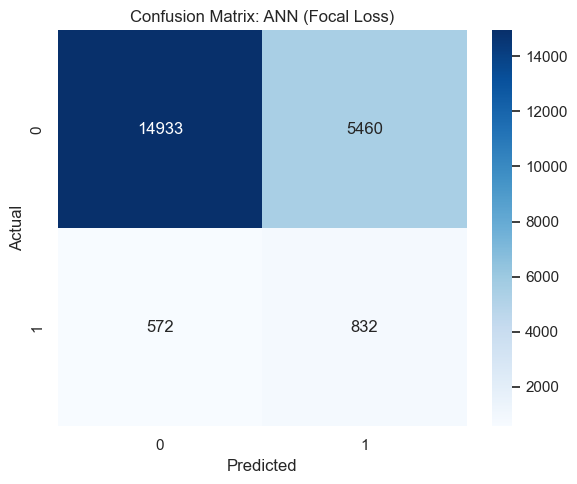

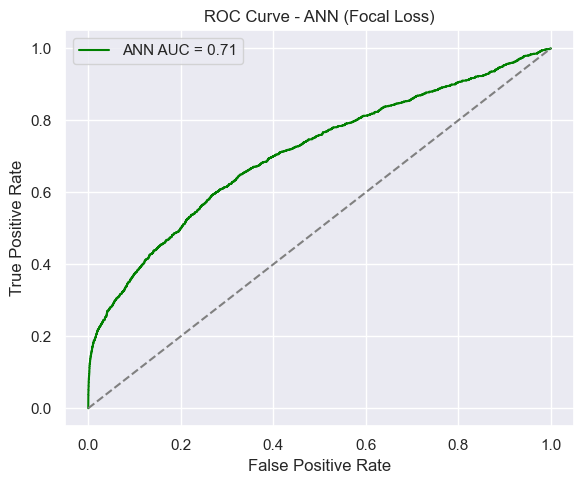

In [22]:
# Predict probabilities
y_proba_ann = keras_clf.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_ann, recall_ann, thresholds_ann = precision_recall_curve(y_test, y_proba_ann)
f2_scores_ann = 5 * (precision_ann * recall_ann) / (4 * precision_ann + recall_ann + 1e-6)
optimal_threshold_ann = thresholds_ann[np.argmax(f2_scores_ann)]
print(f"\nOptimal Threshold (ANN): {optimal_threshold_ann:.4f}")

# Apply threshold
y_pred_ann_opt = (y_proba_ann >= optimal_threshold_ann).astype(int)

# Metrics
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_opt))

roc_auc_ann = roc_auc_score(y_test, y_proba_ann)
print(f"ROC-AUC Score (ANN): {roc_auc_ann:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ann_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: ANN (Focal Loss)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
plt.figure(figsize=(6, 5))
plt.plot(fpr_ann, tpr_ann, label=f"ANN AUC = {roc_auc_ann:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN (Focal Loss)")
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison

### Classification Reports

In [33]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logreg_opt))

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree_opt))

print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf_opt))

print("\nClassification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb_opt))

print("\nClassification Report - ANN")
print(classification_report(y_test, y_pred_ann_opt))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

       False       0.96      0.77      0.86     20393
        True       0.15      0.59      0.24      1404

    accuracy                           0.76     21797
   macro avg       0.56      0.68      0.55     21797
weighted avg       0.91      0.76      0.82     21797


Classification Report - Decision Tree
              precision    recall  f1-score   support

       False       0.97      0.40      0.56     20393
        True       0.08      0.80      0.15      1404

    accuracy                           0.42     21797
   macro avg       0.53      0.60      0.36     21797
weighted avg       0.91      0.42      0.54     21797


Classification Report - Random Forest
              precision    recall  f1-score   support

       False       0.97      0.67      0.79     20393
        True       0.12      0.65      0.20      1404

    accuracy                           0.67     21797
   mac

### General Comparison

In [29]:
def compute_f2(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "ANN"],
    "F2 Score": [
        compute_f2(y_test, y_pred_logreg_opt),
        compute_f2(y_test, y_pred_tree_opt),
        compute_f2(y_test, y_pred_rf_opt),
        compute_f2(y_test, y_pred_xgb_opt),
        compute_f2(y_test, y_pred_ann_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg_opt),
        recall_score(y_test, y_pred_tree_opt),
        recall_score(y_test, y_pred_rf_opt),
        recall_score(y_test, y_pred_xgb_opt),
        recall_score(y_test, y_pred_ann_opt)
    ],
    "ROC AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_ann
    ]
})

display(model_results.sort_values(by="F2 Score", ascending=False).reset_index(drop=True))

,Model,F2 Score,Recall,ROC AUC
0,XGBoost,0.373338,0.603989,0.741939
1,Logistic Regression,0.370702,0.589744,0.725700
2,ANN,0.349345,0.592593,0.708073
3,Random Forest,0.343639,0.646011,0.706736
4,Decision Tree,0.296265,0.803419,0.651130


### ROC Curve Comparison

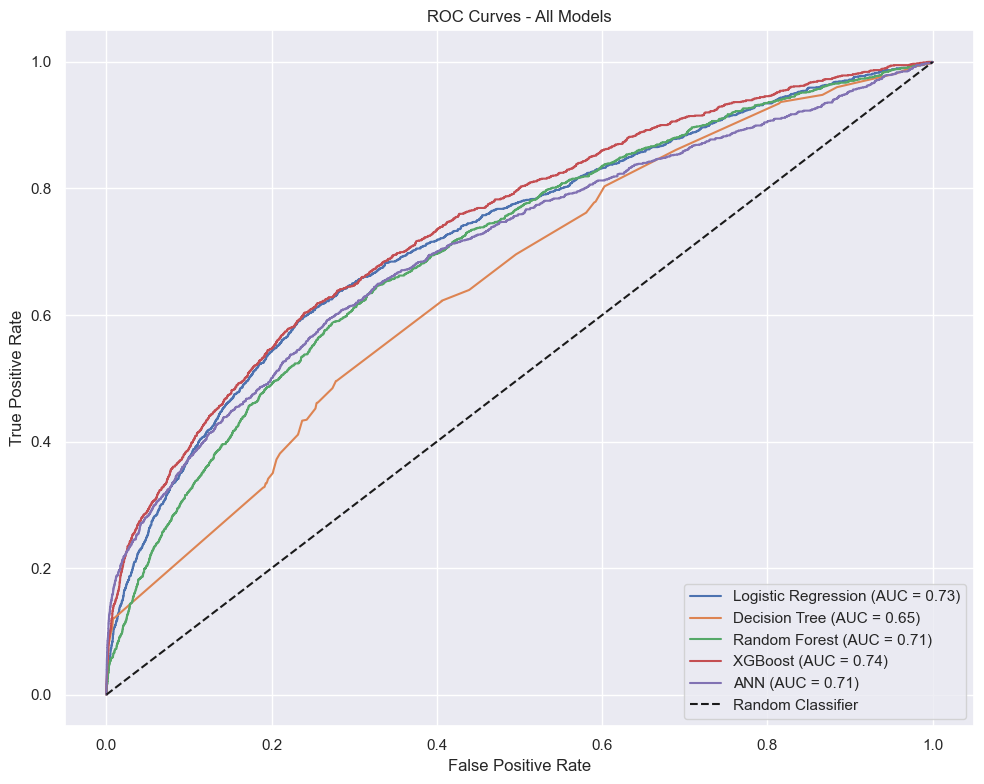

In [30]:
# Compute ROC curve data for each model
roc_data = []

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
roc_data.append(("Logistic Regression", fpr, tpr, roc_auc))

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_data.append(("Decision Tree", fpr, tpr, roc_auc_tree))

# Random Forest
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_data.append(("Random Forest", fpr, tpr, roc_auc_rf))

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_data.append(("XGBoost", fpr, tpr, roc_auc_xgb))

# ANN
fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
roc_data.append(("ANN", fpr, tpr, roc_auc_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, fpr, tpr, auc_score in roc_data:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Precision Recall Curve

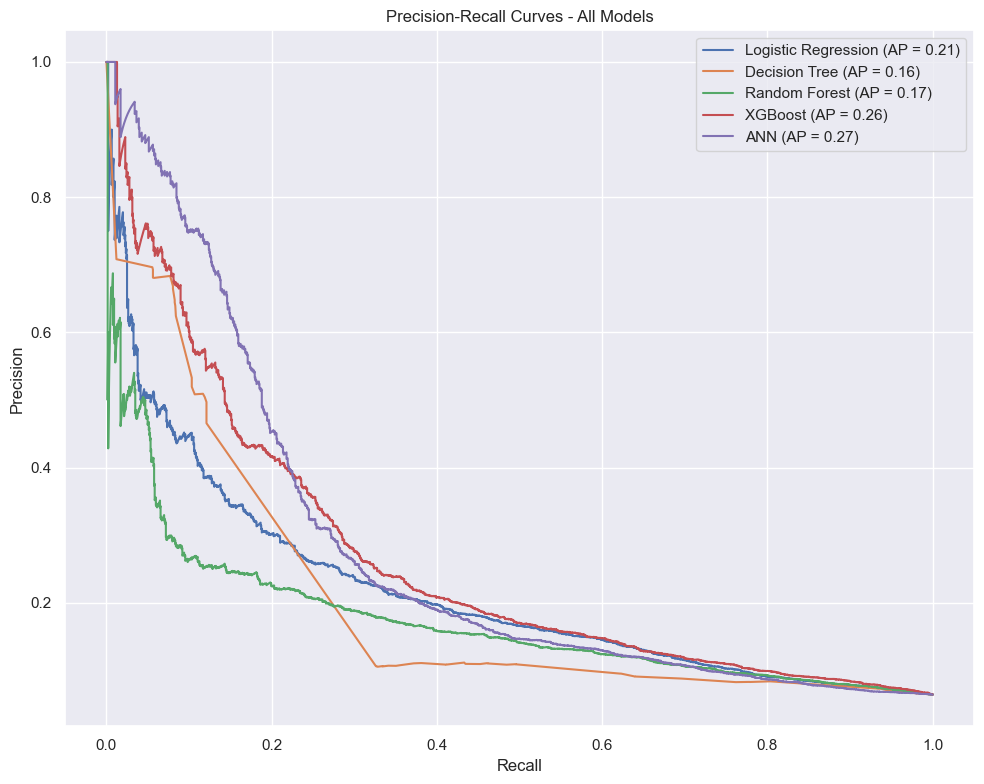

In [32]:
# Compute Precision-Recall curve data
pr_data = []

# Logistic Regression
precision, recall, _ = precision_recall_curve(y_test, y_proba_logreg)
ap_logreg = average_precision_score(y_test, y_proba_logreg)
pr_data.append(("Logistic Regression", precision, recall, ap_logreg))

# Decision Tree
precision, recall, _ = precision_recall_curve(y_test, y_proba_tree)
ap_tree = average_precision_score(y_test, y_proba_tree)
pr_data.append(("Decision Tree", precision, recall, ap_tree))

# Random Forest
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)
pr_data.append(("Random Forest", precision, recall, ap_rf))

# XGBoost
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
pr_data.append(("XGBoost", precision, recall, ap_xgb))

# ANN
precision, recall, _ = precision_recall_curve(y_test, y_proba_ann)
ap_ann = average_precision_score(y_test, y_proba_ann)
pr_data.append(("ANN", precision, recall, ap_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, precision, recall, ap_score in pr_data:
    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Importance

<Figure size 1000x800 with 0 Axes>

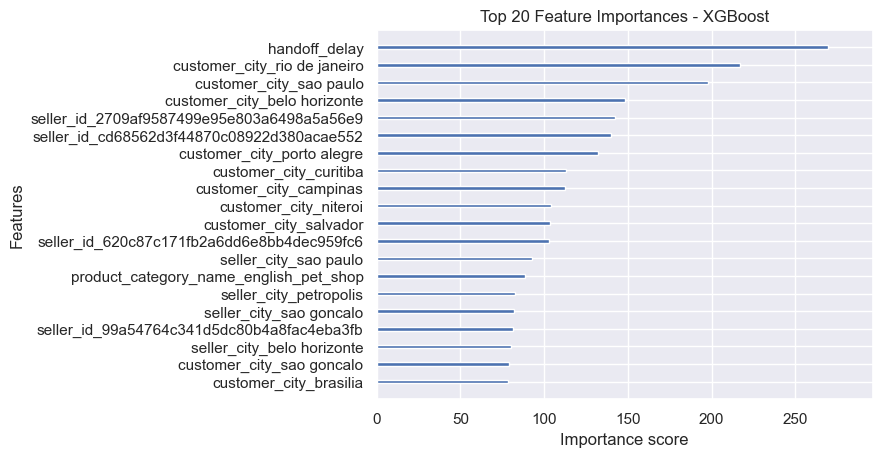

In [34]:
plt.figure(figsize=(10, 8))
plot_importance(best_xgb, max_num_features=20, importance_type='gain', show_values=False)
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()